We have a steam turbine that can work efficiently when the Temperature and Pressure are in a certain range of values.
If the pressure or the temperature or both are too low, then a valve can turn from 0 to -90 degrees in order to let more vapor enter the turbine.
On the other hand, when the pressure or the temperature are too high, the the valve turns from 0 to 90 degrees to allow steam to exit the turbine.
Thus, we construct a fuzzy inference system which is based on some empirical rules in order to maintain the efficiency of the turbine through controlling the valve.

In [1]:
# first we inport the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

print('done')

done


In [2]:
# Step 1: Define fuzzy variables (Temperature, Pressure, Valve Position)

# the Temperature inside the turbine ranges from 400K to 700K
temperature = ctrl.Antecedent(np.arange(400, 701, 1), 'temperature')

# the Pressure inside the turbine ranges from 500 to 1000 psgi
pressure = ctrl.Antecedent(np.arange(500, 1001, 1), 'pressure')

# The Valve rotation degrees varies from -90 to 90 degrees
valve = ctrl.Consequent(np.arange(-90, 91, 1), 'valve')

print('done')

done


C:\Users\anton\anaconda3\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Text(0.5, 1.0, 'Valve Position Membership Functions')

<Figure size 1000x600 with 0 Axes>

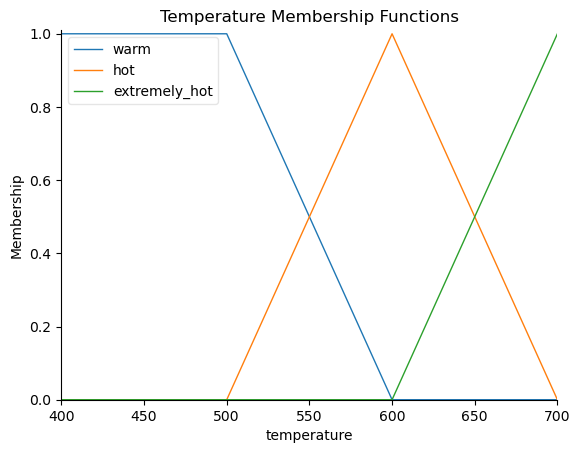

<Figure size 1000x600 with 0 Axes>

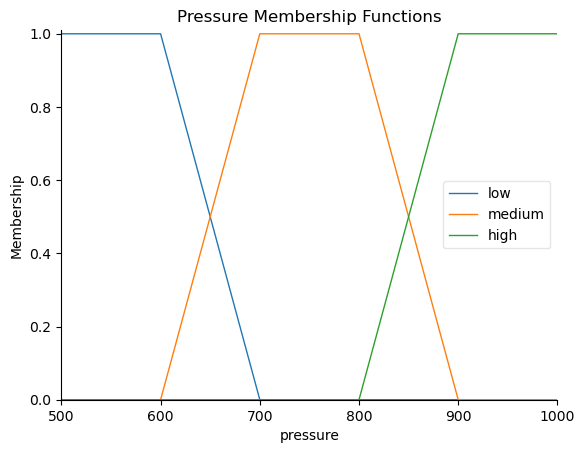

<Figure size 1000x600 with 0 Axes>

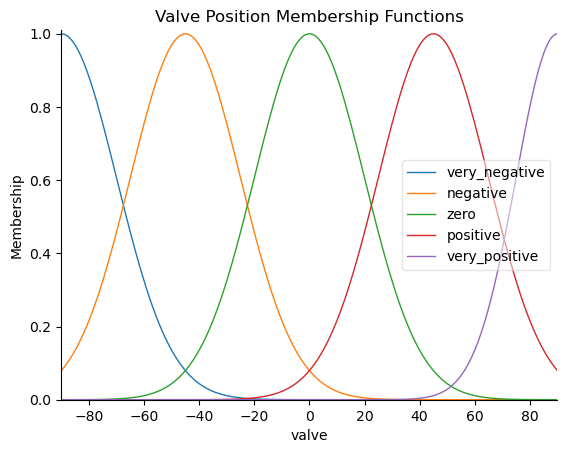

In [3]:
# Step 2: Define fuzzy membership functions
# crisp input variables : 1)Temperature  2)Pressure
# crisp output variable: Valve rotation degrees

# here we define the Temperature membership function 
temperature['warm'] = fuzz.trapmf(temperature.universe, [400, 400, 500, 600])
temperature['hot'] = fuzz.trimf(temperature.universe, [500, 600, 700])
temperature['extremely_hot'] = fuzz.trimf(temperature.universe, [600, 700, 700])

plt.figure(figsize=(10, 6))
temperature.view()
plt.title('Temperature Membership Functions')

# here we define he Pressure membership function
pressure['low'] = fuzz.trapmf(pressure.universe, [500, 500, 600, 700])
pressure['medium'] = fuzz.trapmf(pressure.universe, [600, 700, 800, 900])
pressure['high'] = fuzz.trapmf(pressure.universe, [800, 900, 1000,1000])

plt.figure(figsize=(10, 6))
pressure.view()
plt.title('Pressure Membership Functions')

# here we define the fuzzy membership functions for Valve Rotation
valve['very_negative'] = fuzz.gaussmf(valve.universe, mean=-90, sigma=20)
valve['negative'] = fuzz.gaussmf(valve.universe, mean=-45, sigma=20)
valve['zero'] = fuzz.gaussmf(valve.universe, mean=0, sigma=20)
valve['positive'] = fuzz.gaussmf(valve.universe, mean=45, sigma=20)
valve['very_positive'] = fuzz.gaussmf(valve.universe, mean=90, sigma=15)

plt.figure(figsize=(10, 6))
valve.view()
plt.title('Valve Position Membership Functions')

In [4]:
# Step 5: Define fuzzy rules

'''
                        low                   medium                    high
warm          |    very_negative               zero                   positive
hot           |       negative                 zero                 very_positive
extremely_hot |       negative               positive               very_positive

'''
rule1 = ctrl.Rule(temperature['extremely_hot'] & pressure['low'], valve['negative'])
rule2 = ctrl.Rule(temperature['extremely_hot'] & pressure['medium'], valve['positive'])
rule3 = ctrl.Rule(temperature['extremely_hot'] & pressure['high'], valve['very_positive'])

rule4 = ctrl.Rule(temperature['hot'] & pressure['low'], valve['negative'])
rule5 = ctrl.Rule(temperature['hot'] & pressure['medium'], valve['zero'])
rule6 = ctrl.Rule(temperature['hot'] & pressure['high'], valve['very_positive'])

rule7 = ctrl.Rule(temperature['warm'] & pressure['low'], valve['very_negative'])
rule8 = ctrl.Rule(temperature['warm'] & pressure['medium'], valve['zero'])
rule9 = ctrl.Rule(temperature['warm'] & pressure['high'], valve['positive'])

print('done')

done


In [5]:
# Step 6: Control system creation and simulation
turbine_control_system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
turbine_simulator = ctrl.ControlSystemSimulation(turbine_control_system)

print('done')

done


In [6]:
# Step 7a: Set input values and compute output for example

# Example inputs: temperature = 650K, pressure = 750 psgi
turbine_simulator.input['temperature'] = 650
turbine_simulator.input['pressure'] = 750

# Compute the output (valve position)
turbine_simulator.compute()

# Output the valve position
print(f"Recommended Valve Position: {round(turbine_simulator.output['valve'])} degrees")

Recommended Valve Position: 22 degrees


In [9]:
# Step 7b: Compute the valve position output for the whole input range

temperature      = np.arange(400, 701, 10)
pressure         = np.arange(500, 1001, 10)
rotation         = np.zeros((len(temperature),len(pressure)))

for i, temp in enumerate(temperature):
    for j, pres in enumerate(pressure):
        turbine_simulator.input['temperature'] = temp
        turbine_simulator.input['pressure'] = pres
        turbine_simulator.compute()
        rotation[i, j] = turbine_simulator.output['valve']


'''
plt.figure(figsize=(10, 6))
X, Y = np.meshgrid(temperature,pressure)
plt.contourf(X, Y, rotation, 20, cmap='coolwarm')
plt.colorbar(label='Valve Position (degrees)')
plt.xlabel('Pressure (psgi)')
plt.ylabel('Temperature (K)')
plt.title('Valve Position Output for All Input Combinations')
plt.show()
'''

"\nplt.figure(figsize=(10, 6))\nX, Y = np.meshgrid(temperature,pressure)\nplt.contourf(X, Y, rotation, 20, cmap='coolwarm')\nplt.colorbar(label='Valve Position (degrees)')\nplt.xlabel('Pressure (psgi)')\nplt.ylabel('Temperature (K)')\nplt.title('Valve Position Output for All Input Combinations')\nplt.show()\n"

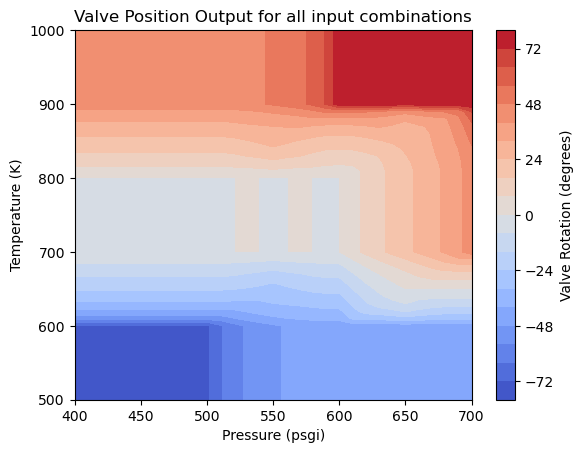

Text(0.5, 0.92, 'Valve Position Output for all input combinations')

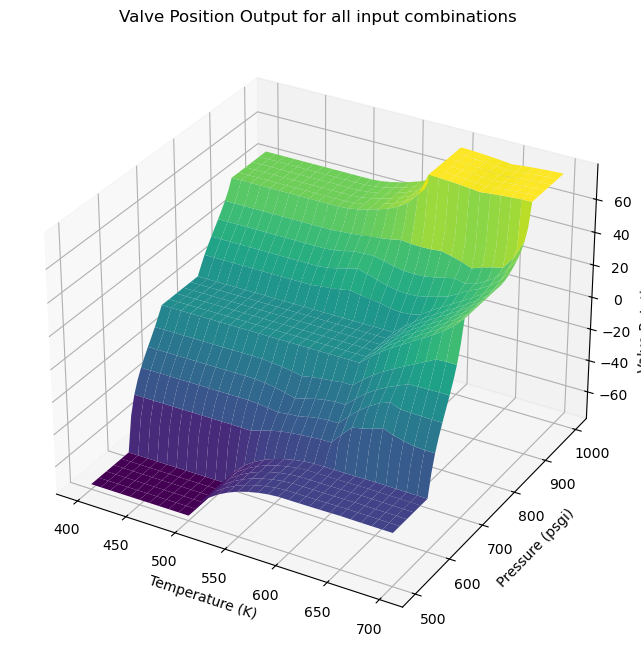

In [31]:
# Step 7b: Plot the valve position output for the whole input range
X, Y = np.meshgrid(temperature,pressure)

plt.contourf(X,Y,rotation.transpose(), 20, cmap='coolwarm')
plt.colorbar(label='Valve Rotation (degrees)')
plt.xlabel('Pressure (psgi)')
plt.ylabel('Temperature (K)')
plt.title('Valve Position Output for all input combinations')
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, rotation.transpose(), cmap='viridis')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Pressure (psgi)')
ax.set_zlabel('Valve Rotation (degrees)')
ax.set_title('Valve Position Output for all input combinations')